# Quantitative Finance: Stock Price Movement Predictor
Building an end-to-end machine learning pipeline using a Random Forest Classifier to predict daily asset direction based on historical stock trends.

### Project Stages:
1. **Data Acquisition:** Fetching live data via the Yahoo Finance API (`yfinance`).
2. **Data Preprocessing:** Engineering time-series targets and rolling averages.
3. **Model Training:** Implementing a chronological split to prevent future data leakage.
4. **Visualization:** Plotting a 50-day prediction snapshot using `matplotlib`.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Download historical data for Apple (AAPL)
print("Downloading Apple stock data...")
data = yf.download("AAPL", start="2020-01-01", end="2026-01-01")

# 2. Calculate daily financial indicators (Features)
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['5_Day_MA'] = data['Close'].rolling(window=5).mean()
data['20_Day_MA'] = data['Close'].rolling(window=20).mean()

# 3. Create our target: Will tomorrow's close price be higher than today's?
# 1 = Up, 0 = Down
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

# Clean up empty rows caused by calculating averages
data.dropna(inplace=True)

print("Data successfully loaded and prepared!")
print(data[['Close', '5_Day_MA', 'Target']].head())

[*********************100%***********************]  1 of 1 completed

Data successfully loaded and prepared!
Price           Close   5_Day_MA Target
Ticker           AAPL                  
Date                                   
2020-01-30  77.998230  76.736766      0
2020-01-31  74.539902  76.312901      0
2020-02-03  74.335159  76.298923      1
2020-02-04  76.789253  76.354794      1
2020-02-05  77.415428  76.215594      1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Define our Features (X) and our Target (Y)
X = data[['Close', 'Volume', '5_Day_MA', '20_Day_MA']]
y = data['Target']

# 2. Split the data chronologically (train on older data, test on recent data)
# In finance, we don't shuffle data because we cannot predict the past using the future!
split_index = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. Initialize and train the Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate how well the model guesses the test data
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Prediction Accuracy: {accuracy:.2%}\n")
print("Detailed Report:")
print(classification_report(y_test, predictions))

Model Prediction Accuracy: 51.01%

Detailed Report:
              precision    recall  f1-score   support

           0       0.48      0.60      0.53       138
           1       0.56      0.43      0.49       160

    accuracy                           0.51       298
   macro avg       0.52      0.52      0.51       298
weighted avg       0.52      0.51      0.51       298



Matplotlib is building the font cache; this may take a moment.


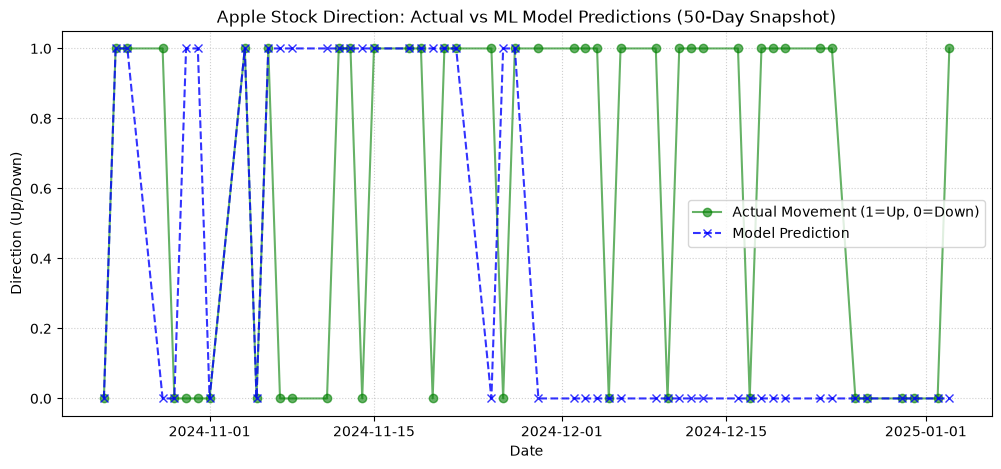

In [7]:
import matplotlib.pyplot as plt

# 1. Take a small 50-day slice of your test data so the chart isn't too crowded
chart_data = y_test.iloc[:50].to_frame()
chart_data['Predicted'] = predictions[:50]

# 2. Plot the Actual vs Predicted direction
plt.figure(figsize=(12, 5))
plt.plot(chart_data.index, chart_data['Target'], label='Actual Movement (1=Up, 0=Down)', color='g', alpha=0.6, marker='o')
plt.plot(chart_data.index, chart_data['Predicted'], label='Model Prediction', color='b', linestyle='--', alpha=0.8, marker='x')

plt.title('Apple Stock Direction: Actual vs ML Model Predictions (50-Day Snapshot)')
plt.xlabel('Date')
plt.ylabel('Direction (Up/Down)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()